In [3]:
# Files from task2_data folder 

import pandas as pd 

# Given features from specifications 
additional_features_df = pd.read_csv('task2_data/additional_features.csv')
# Colour histograms
color_histogram_df = pd.read_csv('task2_data/color_histogram.csv')
# HOG features reduced by PCA
hog_pca_df = pd.read_csv('task2_data/hog_pca.csv')
# Unchanged Test data
test_metadata_df = pd.read_csv('task2_data/test_metadata.csv')
# Unchanged Training data 
train_metadata_df = pd.read_csv('task2_data/train_metadata.csv')


**Task 2: SVM**

In [10]:
# https://www.youtube.com/watch?v=7K-gnWlgAt8
# Extracting features from RESNET - doing own feature engineering 
import torch
from torchvision import models, transforms
import numpy
from PIL import Image
import os

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.eval()


transform_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )  
])

feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
BASE_DIR = os.getcwd() + "/task2_data/"

def extract_features(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform_pipeline(image)
    image = image.unsqueeze(0)
    with torch.no_grad():
        features = feature_extractor(image)
    features = features.detach().numpy().flatten()
    return features 

features_list = []
for idx, row in train_metadata_df.iterrows():
    image_path = os.path.join(BASE_DIR, row["image_path"])
    feats = extract_features(image_path)
    features_list.append(feats)

features_df = pd.DataFrame(features_list, index=train_metadata_df["image_id"])




Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy: 0.8871772805507746
Test accuracy: 0.8872901678657075
F1 score: 0.8874907572664453


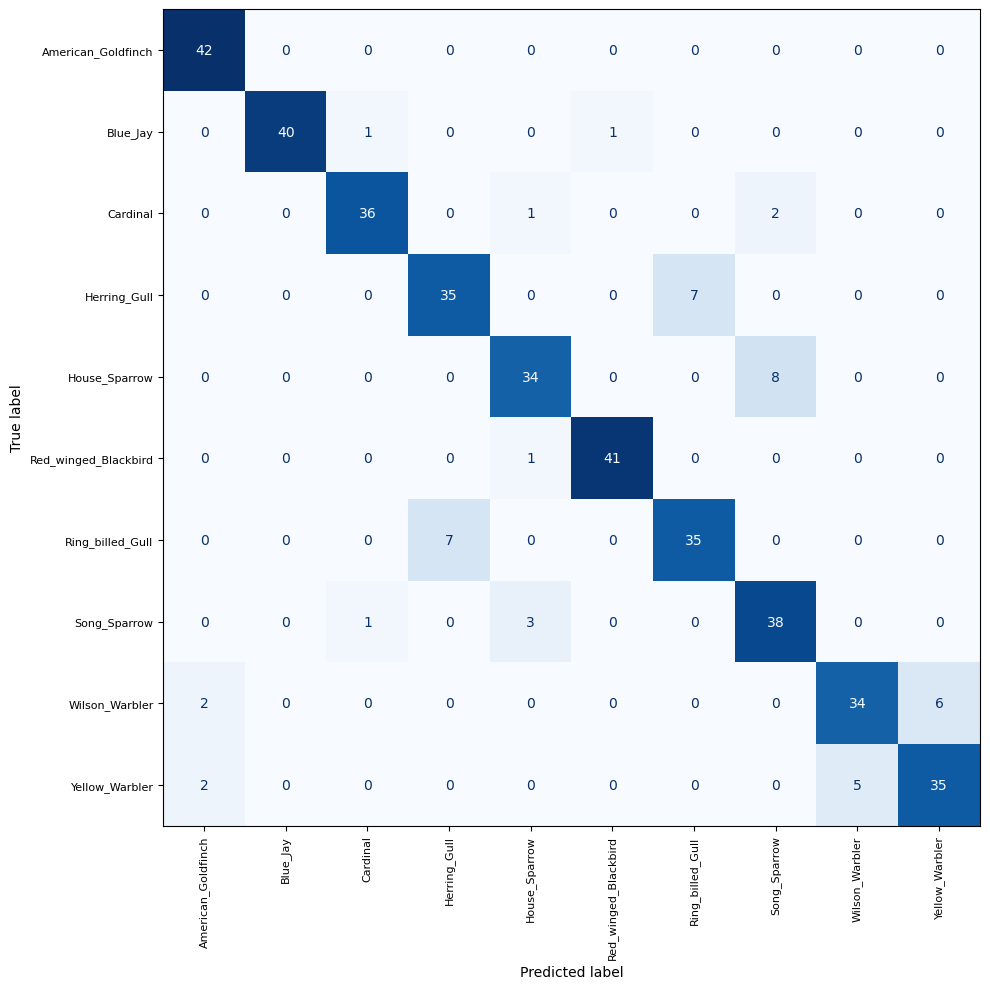

F1 Scores
[0.95454545 0.97560976 0.93506494 0.83333333 0.83950617 0.97619048
 0.83333333 0.84444444 0.83950617 0.84337349]
Recall scores
[1.         0.95238095 0.92307692 0.83333333 0.80952381 0.97619048
 0.83333333 0.9047619  0.80952381 0.83333333]
Precision scores
[0.91304348 1.         0.94736842 0.83333333 0.87179487 0.97619048
 0.83333333 0.79166667 0.87179487 0.85365854]
Overall accuracy
0.8872901678657075


<Figure size 640x480 with 0 Axes>

In [11]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn import svm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict

# Associate features with correct labels for training purposes 
additional_features_merged = pd.merge(train_metadata_df, features_df, on="image_id")


X = additional_features_merged.drop(columns=["image_id", "class_name", "image_path", "class_id"])
y = additional_features_merged["class_id"]


# Hyperparameter tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'], 
    'gamma': ['scale', 'auto']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_model = GridSearchCV(
    svm.SVC(),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

svm_model.fit(X, y)

print("Best parameters:", svm_model.best_params_)
print("Best CV accuracy:", svm_model.best_score_)

# Evaluate on local test set
best_model = svm_model.best_estimator_
y_prediction_cv = cross_val_predict(best_model, X, y, cv=cv)

print("Test accuracy:", accuracy_score(y, y_prediction_cv))
print("F1 score:", f1_score(y, y_prediction_cv, average='macro'))

# Confusion matrix
class_names = additional_features_merged["class_name"].unique()

cm = confusion_matrix(y, y_prediction_cv,)

fig, ax = plt.subplots(figsize=(10, 10)) 

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(
    ax=ax,
    xticks_rotation=90,  
    cmap="Blues",
    colorbar=False
)

# smaller font for labels
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.savefig("confusion_matrix_svm.png", dpi=300, bbox_inches="tight")
plt.show()
plt.savefig("svm_confusion_task2.png")

# Predict on local test set and Kaggle
def predict_SVM(image_paths):
    specific_features = []
    for image_path in image_paths:
        image_path = os.path.join(BASE_DIR, image_path)
        specific_features.append(extract_features(image_path))
    predictions = svm_model.predict(specific_features)
    return predictions
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

print("F1 Scores")
f1_svm = f1_score(y, y_prediction_cv, average=None)
print(f1_svm)
print("Recall scores")
recall_svm = recall_score(y, y_prediction_cv, average=None)
print(recall_svm)
print("Precision scores")
precision_svm = precision_score(y, y_prediction_cv, average=None)
print(precision_svm)
print("Overall accuracy")
svm_accuracy = accuracy_score(y, y_prediction_cv)
print(svm_accuracy)


In [ ]:
# House Sparrows as Song Sparrows

# Isolating cats misclassified as dogs
misclassified_house_as_songs = pd.DataFrame({
    "true_label": y,
    "predicted_label": y_prediction_cv
})

misclassified_house_as_songs_ = misclassified_house_as_songs[
    (misclassified_house_as_songs["true_label"] == 4) &
    (misclassified_house_as_songs["predicted_label"] == 7)
]

print(misclassified_house_as_songs_)

In [ ]:
# predicting for Kaggle
kaggle_predictions_svm = predict_SVM(test_metadata_df["image_path"])

submission_df = pd.DataFrame({
    "image_id": test_metadata_df["image_id"],
    "class_id": kaggle_predictions_svm 
})
submission_df.to_csv("submission_task2_svm_(2).csv", index=False)


**Task 2: Random Forest + Handcrafted features**

In [12]:

!pip install opencv-python
import os
import cv2
import numpy as np
from skimage import io, feature, img_as_ubyte
BASE_DIR = os.getcwd() + "/task2_data/"
from sklearn.cluster import KMeans

# https://dev.to/chidoziemanagwu/implementing-edge-detection-with-python-and-opencv-a-step-by-step-guide-57ab
# https://www.geeksforgeeks.org/machine-learning/image-feature-extraction-using-python/
# Doing edge detection

def process_image_edge_detection(filename):
    image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=5)

    magnitude = np.abs(sobelx)

    hist, _ = np.histogram(magnitude, bins=10, range=(0, np.max(magnitude)+1e-6))
    hist = hist / (np.sum(hist) + 1e-6)

    return np.concatenate([hist, [magnitude.mean(), magnitude.std()]])

# Detecting SIFT Features 
# SIFT stands for Scale-Invariant Feature Transform
# Aims to find and match unique points in images

def extract_SIFT(filename):
    image = cv2.imread(filename)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    return descriptors

def build_vocabulary(descriptor_list):
    descriptor_list = [d for d in descriptor_list if d is not None]
    all_descriptors = np.vstack(descriptor_list)
    kmeans = KMeans(
        n_clusters=100,
        random_state=42,
        n_init=10
    )
    kmeans.fit(all_descriptors)
    return kmeans

def process_SIFT(filename, kmeans):
    descriptors = extract_SIFT(filename)
    k = kmeans.n_clusters
    hist = np.zeros(k)
    if descriptors is None:
        return hist
    clusters = kmeans.predict(descriptors)
    # Building a BoVW
    for c in clusters:
        hist[c] += 1
    if hist.sum() > 0:
        hist = hist / hist.sum()

    return hist


descriptor_list = []
for idx, row in train_metadata_df.iterrows():
    image_path = os.path.join(BASE_DIR, row["image_path"])
    desc = extract_SIFT(image_path)
    descriptor_list.append(desc)

kmeans = build_vocabulary(descriptor_list)
sift_features_list = []

for idx, row in train_metadata_df.iterrows():
    image_path = os.path.join(BASE_DIR, row["image_path"])
    feats = process_SIFT(image_path, kmeans)
    sift_features_list.append(feats)
columns = [f"sift_{i}" for i in range(100)]
sift_features_array = np.array(sift_features_list)

sift_df = pd.DataFrame(sift_features_array, columns=columns)
sift_df["class_id"] = train_metadata_df["class_id"].values

print(sift_df.shape)


# Extracting texture features
def process_texture(filename):
    image = io.imread(filename, as_gray=True)
    image = img_as_ubyte(image)
    lbp = feature.local_binary_pattern(image, P=8, R=1,method='uniform')
    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    return hist

edge_features_list = []
for idx, row in train_metadata_df.iterrows():
    image_path = os.path.join(BASE_DIR, row["image_path"])
    feats = process_image_edge_detection(image_path)
    edge_features_list.append(feats)

edge_features_array = np.array(edge_features_list)

num_features = edge_features_array.shape[1]
columns = [f"edge_{i}" for i in range(num_features)]

edge_df = pd.DataFrame(edge_features_array, columns=columns)
edge_df["class_id"] = train_metadata_df["class_id"].values


texture_features_list = []
for idx, row in train_metadata_df.iterrows():
    image_path = os.path.join(BASE_DIR, row["image_path"])
    feats =  process_texture(image_path)
    texture_features_list.append(feats)
n_bins = len(texture_features_list[0])
columns = [f"texture_{i}" for i in range(n_bins)]
texture_df = pd.DataFrame(texture_features_list, columns=columns)
texture_df["class_id"] = train_metadata_df["class_id"].values
print(texture_df.shape)



    

libpng warning: iCCP: profile 'ICC Profile': 'desc': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'wtpt': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'bkpt': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'rXYZ': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'gXYZ': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'bXYZ': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'dmnd': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'dmdd': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'vued': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'view': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'lumi

(417, 101)


libpng warning: iCCP: profile 'ICC Profile': 'desc': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'wtpt': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'bkpt': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'rXYZ': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'gXYZ': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'bXYZ': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'dmnd': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'dmdd': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'vued': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'view': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'lumi

(417, 11)


In [13]:
combined_features_df = pd.concat([
    additional_features_df[0:417].drop(columns=["class_id"], errors="ignore").reset_index(drop=True),

    color_histogram_df[0:417].drop(columns=["class_id"], errors="ignore").reset_index(drop=True),

    hog_pca_df[0:417].drop(columns=["class_id"], errors="ignore").reset_index(drop=True),

    texture_df.drop(columns=["class_id"], errors="ignore").reset_index(drop=True),

    edge_df.drop(columns=["class_id"], errors="ignore").reset_index(drop=True),

    sift_df.drop(columns=["class_id"], errors="ignore").reset_index(drop=True)

], axis=1)

In [14]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.feature_selection import f_classif
import numpy as np


X = combined_features_df.drop(columns=['image_id'])
y = train_metadata_df["class_id"]
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({
    "feature": X.columns,
    "mi_score": mi_scores
}).sort_values(by="mi_score", ascending=False)
print(mi_df.head(20))

pipe = Pipeline([
    ("select", SelectKBest(score_func=f_classif)),
    ("rf", RandomForestClassifier(
        n_estimators=600,
        max_depth=25,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=1
    ))
])
param_grid = {
    "select__k": [20, 50, 100, 150, 200]
}

top_n_values = [20, 50, 100, 150, 200]
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=1,
)
grid.fit(X, y)
print("Best k: ", grid.best_params_)
print("Best CV accuracy: ", grid.best_score_)
best_model = grid.best_estimator_
y_pred = np.zeros(len(y))

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train = y.iloc[train_idx]

    best_model.fit(X_train, y_train)
    y_pred[test_idx] = best_model.predict(X_test)
selected_features = mi_df["feature"].head(grid.best_params_["select__k"]).values



def predict_image_class(image_path, image_id):

    additional_feats = additional_features_df.set_index("image_id").loc[image_id]
    additional_feats = additional_feats.drop("class_id", errors="ignore")

    color_feats = color_histogram_df.set_index("image_id").loc[image_id]
    color_feats = color_feats.drop("class_id", errors="ignore")

    hog_feats = hog_pca_df.set_index("image_id").loc[image_id]
    hog_feats = hog_feats.drop("class_id", errors="ignore")

    edge_feats = process_image_edge_detection(image_path)
    sift_feats = process_SIFT(image_path, kmeans)
    texture_feats = process_texture(image_path)

    edge_feats = pd.Series(edge_feats, index=[f"edge_{i}" for i in range(len(edge_feats))])
    sift_feats = pd.Series(sift_feats, index=[f"sift_{i}" for i in range(len(sift_feats))])
    texture_feats = pd.Series(texture_feats, index=[f"texture_{i}" for i in range(len(texture_feats))])

    combined = pd.concat([
        additional_feats,
        color_feats,
        hog_feats,
        texture_feats,
        edge_feats,
        sift_feats
    ])
    combined = combined.to_frame().T
    combined = combined.reindex(columns=X.columns)

    combined = combined.fillna(0)

    return best_model.predict(combined)[0]

def predict_random_forest(image_paths, image_ids):

    predictions = []

    for image_path, image_id in zip(image_paths, image_ids):
        full_path = os.path.join(BASE_DIR, image_path)
        predictions.append(predict_image_class(full_path, image_id))

    return predictions



       feature  mi_score
119  hog_pca_0  0.207874
231     edge_2  0.160607
239    edge_10  0.159238
236     edge_7  0.156717
235     edge_6  0.148800
7       feat_7  0.144216
59    color_36  0.138750
96    color_73  0.137248
232     edge_3  0.134174
228  texture_9  0.132545
259    sift_18  0.130761
229     edge_0  0.124017
291    sift_50  0.118842
91    color_68  0.117131
233     edge_4  0.116729
221  texture_2  0.113752
25     color_2  0.108156
68    color_45  0.106846
67    color_44  0.106589
80    color_57  0.106225
Best k:  {'select__k': 200}
Best CV accuracy:  0.33577165806081466


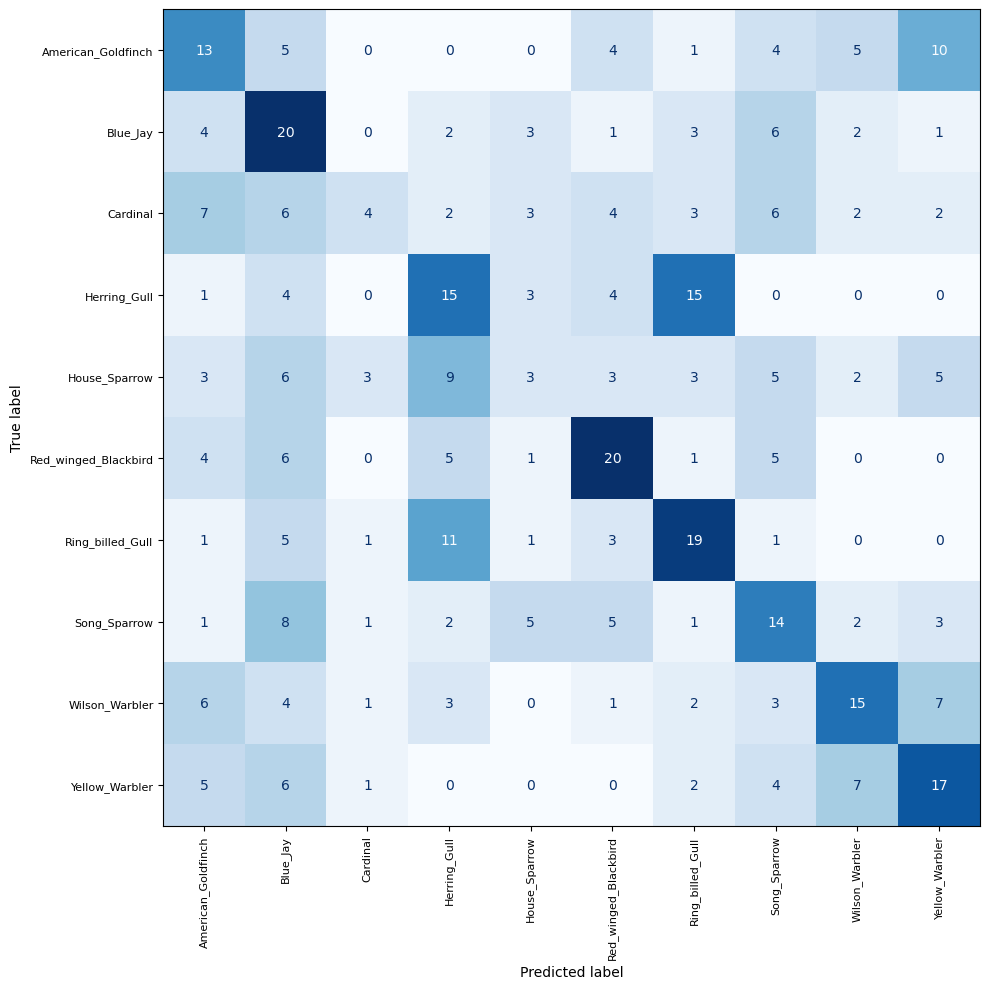

F1 Scores
[0.29885057 0.35714286 0.16       0.32967033 0.09836066 0.45977011
 0.41304348 0.31111111 0.38961039 0.3908046 ]
Recall scores
[0.30952381 0.47619048 0.1025641  0.35714286 0.07142857 0.47619048
 0.45238095 0.33333333 0.35714286 0.4047619 ]
Precision scores
[0.28888889 0.28571429 0.36363636 0.30612245 0.15789474 0.44444444
 0.38       0.29166667 0.42857143 0.37777778]
Overall accuracy
0.33573141486810554


<Figure size 640x480 with 0 Axes>

In [15]:
# Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, precision_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score


cm = confusion_matrix(y, y_pred)

fig, ax = plt.subplots(figsize=(10, 10)) 

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(
    ax=ax,
    xticks_rotation=90,   
    cmap="Blues",
    colorbar=False
)

ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.savefig("confusion_matrix_svm.png", dpi=300, bbox_inches="tight")
plt.show()
plt.savefig("rf_confusion_task2.png")


print("F1 Scores")
f1_svm = f1_score(y, y_pred, average=None)
print(f1_svm)
print("Recall scores")
recall_svm = recall_score(y, y_pred, average=None)
print(recall_svm)
print("Precision scores")
precision_svm = precision_score(y, y_pred, average=None)
print(precision_svm)
print("Overall accuracy")
svm_accuracy = accuracy_score(y, y_pred)
print(svm_accuracy)

In [ ]:
misclassified_herring_as_ring = pd.DataFrame({
    "true_label": y,
    "predicted_label": y_pred
})
misclassified_herring_as_ring = misclassified_herring_as_ring[
    (misclassified_herring_as_ring["true_label"] == 3) &
    (misclassified_herring_as_ring["predicted_label"] == 5)
]
print(misclassified_herring_as_ring)



misclassified_house_as_jay = pd.DataFrame({
    "true_label": y,
    "predicted_label": y_pred
})
misclassified_house_as_jay = misclassified_house_as_jay[
    (misclassified_house_as_jay["true_label"] == 4) &
    (misclassified_house_as_jay["predicted_label"] == 1)
]
print(misclassified_house_as_jay)


In [ ]:
# Kaggle submission
kaggle_predictions_random_forest = predict_random_forest(test_metadata_df["image_path"], test_metadata_df["image_id"])
submission_df = pd.DataFrame({
    "image_id": test_metadata_df["image_id"],
    "class_id": kaggle_predictions_random_forest
})
submission_df.to_csv("rf_task2_new_2(1).csv", index=False)

 **Task 2: Bagging**

In [ ]:
import torch
from torchvision import models
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold



resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
resnet.eval()

resnet_feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1])
from efficientnet_pytorch import EfficientNet

effnet = EfficientNet.from_pretrained("efficientnet-b0")
effnet.eval()
from torchvision import transforms
from PIL import Image

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet_feature_extractor = resnet_feature_extractor.to(device)
effnet = effnet.to(device)

def get_resnet_features(image):
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = resnet_feature_extractor(image)

    return features.squeeze().cpu().numpy()

def get_effnet_features(image):
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = effnet.extract_features(image)
        features = effnet._avg_pooling(features)
        features = torch.flatten(features, 1)

    return features.squeeze().cpu().numpy()


import numpy as np
import os

BASE_DIR = os.getcwd() + "/task2_data/"

features_list = []
labels_list = []
for idx, row in train_metadata_df.iterrows():
    img_path = os.path.join(BASE_DIR, row["image_path"])
    image = Image.open(img_path).convert("RGB")

    resnet_feat = get_resnet_features(image)
    eff_feat = get_effnet_features(image)
    combined = np.concatenate([resnet_feat, eff_feat])

    features_list.append(combined)
    labels_list.append(row["class_id"])
X = np.array(features_list)
y = np.array(labels_list)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
def train_bag(X_train, y_train, n_models):
    models = []
    for i in range(n_models):
        X_bag, y_bag = resample(X_train, y_train, replace=True, random_state=42+i)
    
        model = LogisticRegression(max_iter=5000, solver="saga")
        model.fit(X_bag, y_bag)
    
        models.append(model)
    return models
def bagging_predict(models, X):
    preds = [m.predict_proba(X) for m in models]
    return np.argmax(np.mean(preds, axis=0), axis=1)

def bagging_predict(models, X):
    preds = []

    for model in models:
        preds.append(model.predict_proba(X))  
    preds = np.mean(preds, axis=0)  
    return np.argmax(preds, axis=1)




In [ ]:
n_models_list = [1, 3, 5]
results = {}
all_models = {}
for n_models in n_models_list:

    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        models = train_bag(X_train, y_train, n_models)
        preds = bagging_predict(models, X_val)
        all_models[n_models] = models
        

        acc = accuracy_score(y_val, preds)
        fold_scores.append(acc)

    results[n_models] = (np.mean(fold_scores), np.std(fold_scores))

    print(f"n_models={n_models} ---- "
          f"mean={results[n_models][0]:.4f}, "
          f"std={results[n_models][1]:.4f}")

In [ ]:

from sklearn.model_selection import StratifiedKFold
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
for train_idx, val_idx in skf.split(X, y):

    X_train, X_val = X[train_idx], X[val_idx]
    y_train = y[train_idx]

    models = train_bag(X_train, y_train, n_models=3)

    preds = bagging_predict(models, X_val)

    oof_preds[val_idx] = preds
print("Accuracy:", accuracy_score(y, oof_preds))
print("Confusion Matrix:\n", confusion_matrix(y, oof_preds))




In [ ]:
test_features_list = []
for idx, row in test_metadata_df.iterrows():
    img_path = os.path.join(BASE_DIR, row["image_path"])
    image = Image.open(img_path).convert("RGB")

    resnet_feat = get_resnet_features(image)
    eff_feat = get_effnet_features(image)

    combined = np.concatenate([resnet_feat, eff_feat])

    test_features_list.append(combined)
X_test_final = np.array(test_features_list)
test_preds = bagging_predict(final_model, X_test_final)
submission_df = pd.DataFrame({
    "image_id": test_metadata_df["image_id"],
    "class_id": test_preds
})

submission_df.to_csv("submission_bagging_task2(3).csv", index=False)